# K Nearest Neighbors

In [1]:
# Data manipulation libraries.
import numpy as np
import pandas as pd

# Data visualization libraries.
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configure NumPy.
rng = np.random.default_rng(seed=42)
np.set_printoptions(linewidth=100)

# Configure Pandas.
pd.options.display.width = 100

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

## 1 Introduction

### 1.1 Usecase

#### Problem Statement

- Suppose we have a dataset containing many data-points where each data-point belong to a group.
- There are multiple such groups (two or more).
- We a new data-point whose group is unknown and needs to assigned to one of those groups.

#### Solution Approach

- Since there are two or more groups its a Multi-class classification problem.
- Try to locate the group nearest to the new data-point (call it as Query-point).
- Identify the class label of the nearest group and assign it to the Query-point.

### 1.2 Geometrical Intuition

#### Sample Data-points

In [3]:
smp_df = pd.DataFrame(
    {
        "X1": [3, 6, 8, 7, 1, 2],
        "X2": [6, 4, 2, 5, 4, 2],
        "CL": [1, 1, 3, 3, 2, 1],
    }
)
smp_df["CL"] = smp_df["CL"].astype("category")
smp_df

,X1,X2,CL
0,3,6,1
1,6,4,1
2,8,2,3
3,7,5,3
4,1,4,2
5,2,2,1


#### Query Point

In [4]:
qp = [2, 5]  # Query point

#### Plot Query Point

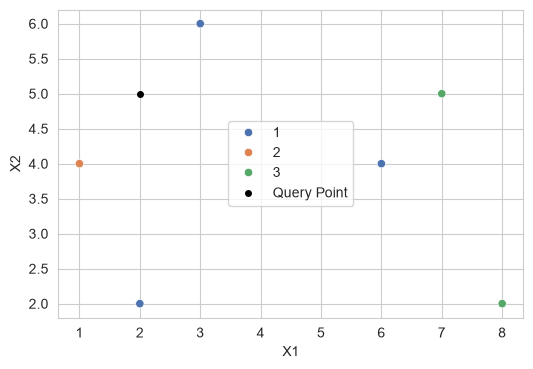

In [5]:
plt.figure(figsize=(6, 4))

sns.scatterplot(data=smp_df, x="X1", y="X2", hue="CL")
plt.plot(qp[0], qp[1], "ko", markersize=4, label="Query Point")
plt.legend(loc="center")

plt.show()

#### Euclidean Distance

In [6]:
def euclidean_distance(X, qp):
    """
    Function to calculate Euclidean Distance
    b/w Data-point: `X` and Query-point: `qp`.
    """
    dist = np.linalg.norm(X - qp, ord=2)
    return dist

### 1.3 Conflict

#### Example #1: No Conflict

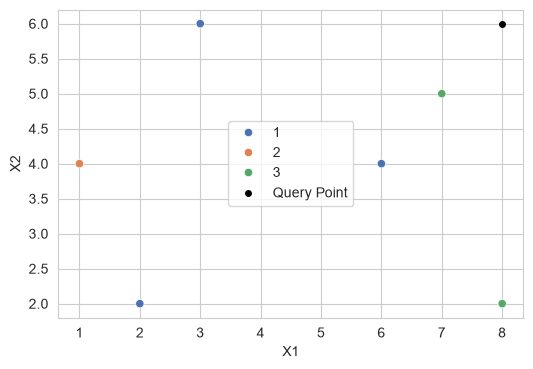

In [7]:
qp = [8, 6]  # Query point

plt.figure(figsize=(6, 4))
sns.scatterplot(data=smp_df, x="X1", y="X2", hue="CL")
plt.plot(qp[0], qp[1], "ko", markersize=4, label="Query Point")
plt.legend(loc="center")
plt.show()

In [8]:
print("Euclidean distance between:")
for idx, dp in smp_df.iterrows():
    x = dp[["X1", "X2"]].values
    y = dp["CL"]
    dist = euclidean_distance(x, qp)
    print(f"data-point:{x} with class-label {y} and query-point:{qp} = {dist:.2f}")

Euclidean distance between:
data-point:[3 6] with class-label 1 and query-point:[8, 6] = 5.00
data-point:[6 4] with class-label 1 and query-point:[8, 6] = 2.83
data-point:[8 2] with class-label 3 and query-point:[8, 6] = 4.00
data-point:[7 5] with class-label 3 and query-point:[8, 6] = 1.41
data-point:[1 4] with class-label 2 and query-point:[8, 6] = 7.28
data-point:[2 2] with class-label 1 and query-point:[8, 6] = 7.21


#### Example #2: Conflict

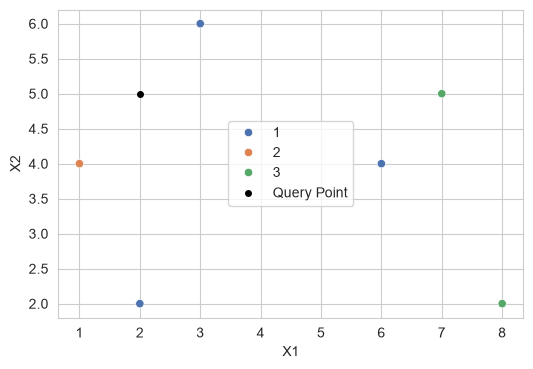

In [9]:
qp = [2, 5]  # Query point

plt.figure(figsize=(6, 4))
sns.scatterplot(data=smp_df, x="X1", y="X2", hue="CL")
plt.plot(qp[0], qp[1], "ko", markersize=4, label="Query Point")
plt.legend(loc="center")
plt.show()

In [10]:
print("Euclidean distance between:")
for idx, dp in smp_df.iterrows():
    x = dp[["X1", "X2"]].values
    y = dp["CL"]
    dist = euclidean_distance(x, qp)
    print(f"data-point:{x} with class-label {y} and query-point:{qp} = {dist:.2f}")

Euclidean distance between:
data-point:[3 6] with class-label 1 and query-point:[2, 5] = 1.41
data-point:[6 4] with class-label 1 and query-point:[2, 5] = 4.12
data-point:[8 2] with class-label 3 and query-point:[2, 5] = 6.71
data-point:[7 5] with class-label 3 and query-point:[2, 5] = 5.00
data-point:[1 4] with class-label 2 and query-point:[2, 5] = 1.41
data-point:[2 2] with class-label 1 and query-point:[2, 5] = 3.00


### 1.4 Mathematical Solution

- Compute the distance between query-point and each data-point.
- Data-points neighboring to the query-point will have smaller distances compared to the distant data-points.
- Sort the distances in ascending order to identify all the nearest neighboring data-points to the query-point.
- There can be multiple data-points at same distance from query-point but with different class-label leading to a conflict.
- To avoid conflict, pick top $K$ nearest neighbors instead of selecting single data-point.
- Vote for class-label among $K$ nearest neighbors and pick the class-label with most votes.
- Choose $K$ as some odd number to avoid conflicting vote among the nearest neighbors.

## 2 KNN Algorithm

### 2.1 K Nearest Neighbors

#### When to choose KNN?

- Dataset does not exhibit clear linear separation.
- Multi-class classification problem.

#### Why not Logistic Regression?

- Polynomial features can be created to fit a non-linear separator, but it increases model **complexity** and may **overfit**.
- Multi-class classification (one-vs-rest) creates multiple models (one for each class label), thus increasing **Training cost**.

#### Properties of KNN

- KNN is non parametric learning.
- There are no learning process involved in KNN.
- Prediction of class-label is based on voting among K nearest Neighbors.

#### Assumptions of KNN

1. Neighborhood is **Homogeneous** i.e., Neighborhood is dominated by similar classes.
2. **Distance** is meaningful.
3. Features should be on **comparable scales**.
4. Dimensionality is not excessively high.
5. Appropriate $K$ is selected.

#### Advantages of KNN

1. Less complex compared to other ML Algorithms.
2. KNN is not affected by class imbalance.
3. Handles Multi-class classification better than Logistic Regression with single model.
4. Non-linear separator.

#### Disadvantages of KNN

1. KNN might fail when there are outliers in the dataset.
2. Since there is non True Learning KNN algorithm is very slow in predictions.

### 2.2 Examples

#### Simple Implementation of KNN steps

In [11]:
def knn_algorithm(df, class_label, query_point, k=5):
    """
    Function to implement KNN Algorithm.
    """
    df_ = df.copy()

    # Select only features from the entire dataset.
    x_cols = df_.columns.difference([class_label])

    # STEP #1: Calculate Euclidean distance between query-point and each data-point.
    df_["distance"] = df_.apply(lambda X: euclidean_distance(X[x_cols].values, query_point), axis=1)

    # STEP #2: Sort distances to identify top K neighbors.
    neighbors = df_.sort_values(by="distance", ascending=True).head(k)

    # STEP #3: Voting among top K class-label and returning
    #          the results with probabilities as predictions.
    y_pred = (
        neighbors[class_label]
        .value_counts(normalize=True)
        .sort_values(ascending=False)
        .round(2)
        .reset_index(name="probs")
    )

    return y_pred

#### Example #1

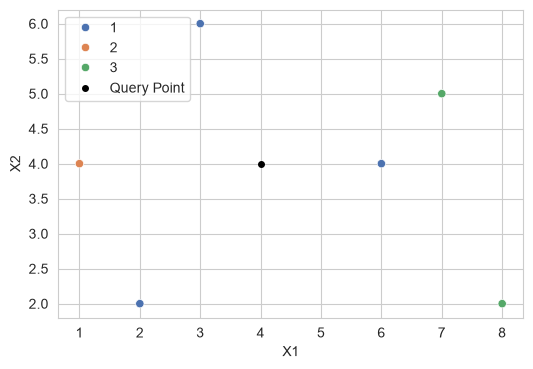

In [12]:
qp = [4, 4]

plt.figure(figsize=(6, 4))

sns.scatterplot(data=smp_df, x="X1", y="X2", hue="CL")
plt.plot(qp[0], qp[1], "ko", markersize=4, label="Query Point")
plt.legend()

plt.show()

In [13]:
top_k_preds = knn_algorithm(df=smp_df, class_label="CL", query_point=qp, k=3)
top_k_preds

,CL,probs
0,1,1.0
1,2,0.0
2,3,0.0


Based on the KNN algorithm, the query point $[4,\,4]$ is predicted as:

In [14]:
qp_y, qp_prob = top_k_preds.iloc[0]
print(f"Query point {qp} is predicted to be of class label: {qp_y} with probability: {qp_prob}")

Query point [4, 4] is predicted to be of class label: 1.0 with probability: 1.0


#### Example #2

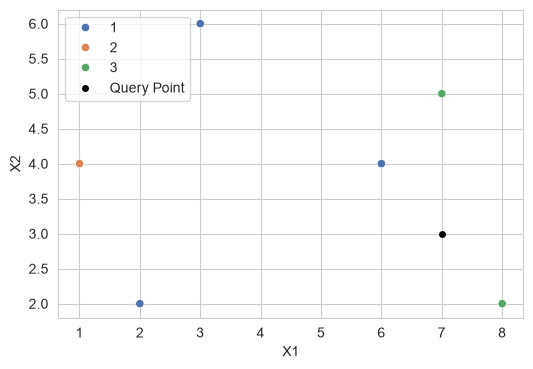

In [15]:
qp = [7, 3]

plt.figure(figsize=(6, 4))

sns.scatterplot(data=smp_df, x="X1", y="X2", hue="CL")
plt.plot(qp[0], qp[1], "ko", markersize=4, label="Query Point")
plt.legend()

plt.show()

In [16]:
top_k_preds = knn_algorithm(df=smp_df, class_label="CL", query_point=qp, k=3)
top_k_preds

,CL,probs
0,3,0.67
1,1,0.33
2,2,0.00


Based on the KNN algorithm, the query point $[7,\,3]$ is predicted as:

In [17]:
qp_y, qp_prob = top_k_preds.iloc[0]
print(f"Query point {qp} is predicted to be of class label: {qp_y} with probability: {qp_prob}")

Query point [7, 3] is predicted to be of class label: 3.0 with probability: 0.67


#### Example #3

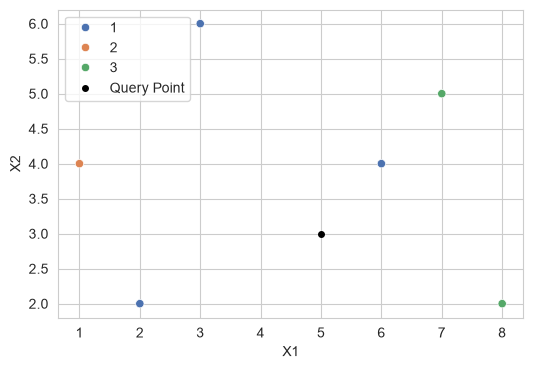

In [18]:
qp = [5, 3]

plt.figure(figsize=(6, 4))

sns.scatterplot(data=smp_df, x="X1", y="X2", hue="CL")
plt.plot(qp[0], qp[1], "ko", markersize=4, label="Query Point")
plt.legend()

plt.show()

In [19]:
top_k_preds = knn_algorithm(df=smp_df, class_label="CL", query_point=qp, k=3)
top_k_preds

,CL,probs
0,3,0.67
1,1,0.33
2,2,0.00


Based on the KNN algorithm, the query point $[5,\,3]$ is predicted as:

In [20]:
qp_y, qp_prob = top_k_preds.iloc[0]
print(f"Query point {qp} is predicted to be of class label: {qp_y} with probability: {qp_prob}")

Query point [5, 3] is predicted to be of class label: 3.0 with probability: 0.67


### 2.3 API

In [21]:
from sklearn.neighbors import KNeighborsClassifier

#### Example

In [22]:
knn_clsfr = KNeighborsClassifier(n_neighbors=3)
knn_clsfr

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None


In [23]:
X_train = smp_df[["X1", "X2"]].values
y_train = smp_df["CL"].values

In [24]:
knn_clsfr.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[1,2,3]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [25]:
qps = [[4, 4], [7, 3], [5, 3]]

qp_y = knn_clsfr.predict(qps)
qp_prob = knn_clsfr.predict_proba(qps)

for idx, qp in enumerate(qps):
    print(
        f"Query point {qp} is predicted to be of class label: {qp_y[idx]}"
        f" with probability: {qp_prob[idx].tolist()}"
    )

Query point [4, 4] is predicted to be of class label: 1 with probability: [1.0, 0.0, 0.0]
Query point [7, 3] is predicted to be of class label: 3 with probability: [0.3333333333333333, 0.0, 0.6666666666666666]
Query point [5, 3] is predicted to be of class label: 3 with probability: [0.3333333333333333, 0.0, 0.6666666666666666]


### 2.4 Challenges with KNN